## Import Libraries

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Load Ground Truth Graph

In [3]:
# Load ground truth graph
with open("ground_truth_graph.json", 'r', encoding='utf-8') as f:
    ground_truth_data = json.load(f)

adjacency_gt = np.array(ground_truth_data['adjacency_matrix'])
gt_variables = ground_truth_data['variables']


## Load Estimated Graphs

In [4]:
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)
    loaded_graphs = loaded_graphs[0:101]


## Metrics Functions

In [10]:
def structural_hamming_distance(adj_true, adj_pred):
    n = len(adj_true)
    diff = np.abs(adj_true - adj_pred)
    additions_deletions = np.sum(diff)
    
    reversals = 0
    for i in range(n):
        for j in range(i + 1, n):
            if (adj_true[i, j] != adj_pred[i, j]) and (adj_true[j, i] != adj_pred[j, i]):
                if (adj_true[i, j] == 1 and adj_pred[j, i] == 1) or \
                   (adj_true[j, i] == 1 and adj_pred[i, j] == 1):
                    reversals += 1
    
    shd = additions_deletions - reversals
    return shd

def normalized_shd(adj_true, adj_pred):
    n = len(adj_true)
    max_edges = n * (n - 1)
    shd = structural_hamming_distance(adj_true, adj_pred)
    return shd / max_edges if max_edges > 0 else 0

def calculate_metrics(adj_true, adj_pred):
    tp = np.sum((adj_true == 1) & (adj_pred == 1))
    fp = np.sum((adj_true == 0) & (adj_pred == 1))
    fn = np.sum((adj_true == 1) & (adj_pred == 0))
    tn = np.sum((adj_true == 0) & (adj_pred == 0))
    
    accuracy = (tp + tn) / (tp + fp + fn + tn) if (tp + fp + fn + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    shd = structural_hamming_distance(adj_true, adj_pred)
    norm_shd = normalized_shd(adj_true, adj_pred)
    
    return {
        'shd': shd,
        'norm_shd': norm_shd,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    }

## Calculate Metrics

In [11]:
all_metrics = []

for idx, graph in enumerate(loaded_graphs):
    if set(graph['variables']) != set(gt_variables):
        continue
    
    adj_pred_raw = np.array(graph['adjacency_matrix'])
    
    if graph['variables'] != gt_variables:
        reorder_indices = [graph['variables'].index(var) for var in gt_variables]
        adj_pred = adj_pred_raw[np.ix_(reorder_indices, reorder_indices)]
    else:
        adj_pred = adj_pred_raw
    
    metrics = calculate_metrics(adjacency_gt, adj_pred)
    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics)

In [12]:
print("probabilistic graphs (llm)")
print(f"shd: {metrics_df['shd'].mean():.2f} ± {metrics_df['shd'].std():.2f}")
print(f"normalized shd: {metrics_df['norm_shd'].mean():.3f} ± {metrics_df['norm_shd'].std():.3f}")
print(f"accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
print(f"precision: {metrics_df['precision'].mean():.3f} ± {metrics_df['precision'].std():.3f}")
print(f"recall: {metrics_df['recall'].mean():.3f} ± {metrics_df['recall'].std():.3f}")
print(f"tp: {metrics_df['tp'].mean():.1f}")
print(f"fp: {metrics_df['fp'].mean():.1f}")
print(f"fn: {metrics_df['fn'].mean():.1f}")
print(f"tn: {metrics_df['tn'].mean():.1f}")

probabilistic graphs (llm)
shd: 9.27 ± 1.24
normalized shd: 0.221 ± 0.030
accuracy: 0.811 ± 0.025
precision: 0.726 ± 0.037
recall: 0.612 ± 0.078
tp: 9.2
fp: 3.4
fn: 5.8
tn: 30.6


## Baseline Graph Analysis

In [25]:
with open("baseline_graph.json", 'r', encoding='utf-8') as f:
    baseline_data = json.load(f)

adjacency_baseline = np.array(baseline_data['adjacency_matrix'])
baseline_variables = baseline_data['variables']

In [26]:
if set(baseline_variables) == set(gt_variables) and baseline_variables != gt_variables:
    reorder_indices = [baseline_variables.index(var) for var in gt_variables]
    adjacency_baseline_reordered = adjacency_baseline[np.ix_(reorder_indices, reorder_indices)]
else:
    adjacency_baseline_reordered = adjacency_baseline

baseline_metrics = calculate_metrics(adjacency_gt, adjacency_baseline_reordered)

In [15]:
print("baseline graph (llm)")
print(f"shd: {baseline_metrics['shd']}")
print(f"normalized shd: {baseline_metrics['norm_shd']:.3f}")
print(f"accuracy: {baseline_metrics['accuracy']:.3f}")
print(f"precision: {baseline_metrics['precision']:.3f}")
print(f"recall: {baseline_metrics['recall']:.3f}")
print(f"tp: {baseline_metrics['tp']}")
print(f"fp: {baseline_metrics['fp']}")
print(f"fn: {baseline_metrics['fn']}")
print(f"tn: {baseline_metrics['tn']}")

baseline graph (llm)
shd: 7
normalized shd: 0.167
accuracy: 0.857
precision: 0.700
recall: 0.933
tp: 14
fp: 6
fn: 1
tn: 28


## Comparison

In [32]:
with open("pc_estimated_graph.json", 'r', encoding='utf-8') as f:
    pc_data = json.load(f)

adjacency_pc = np.array(pc_data['adjacency_matrix'])
pc_variables = pc_data['variables']

In [33]:
if set(pc_variables) == set(gt_variables) and pc_variables != gt_variables:
    reorder_indices = [pc_variables.index(var) for var in gt_variables]
    adjacency_pc_reordered = adjacency_pc[np.ix_(reorder_indices, reorder_indices)]
else:
    adjacency_pc_reordered = adjacency_pc

pc_metrics = calculate_metrics(adjacency_gt, adjacency_pc_reordered)

In [34]:
print("pc algorithm")
print(f"shd: {pc_metrics['shd']}")
print(f"normalized shd: {pc_metrics['norm_shd']:.3f}")
print(f"accuracy: {pc_metrics['accuracy']:.3f}")
print(f"precision: {pc_metrics['precision']:.3f}")
print(f"recall: {pc_metrics['recall']:.3f}")
print(f"tp: {pc_metrics['tp']}")
print(f"fp: {pc_metrics['fp']}")
print(f"fn: {pc_metrics['fn']}")
print(f"tn: {pc_metrics['tn']}")

pc algorithm
shd: 13.0
normalized shd: 0.310
accuracy: 0.714
precision: 0.600
recall: 0.200
tp: 3
fp: 2
fn: 12
tn: 32


## PC Algorithm Graph Analysis

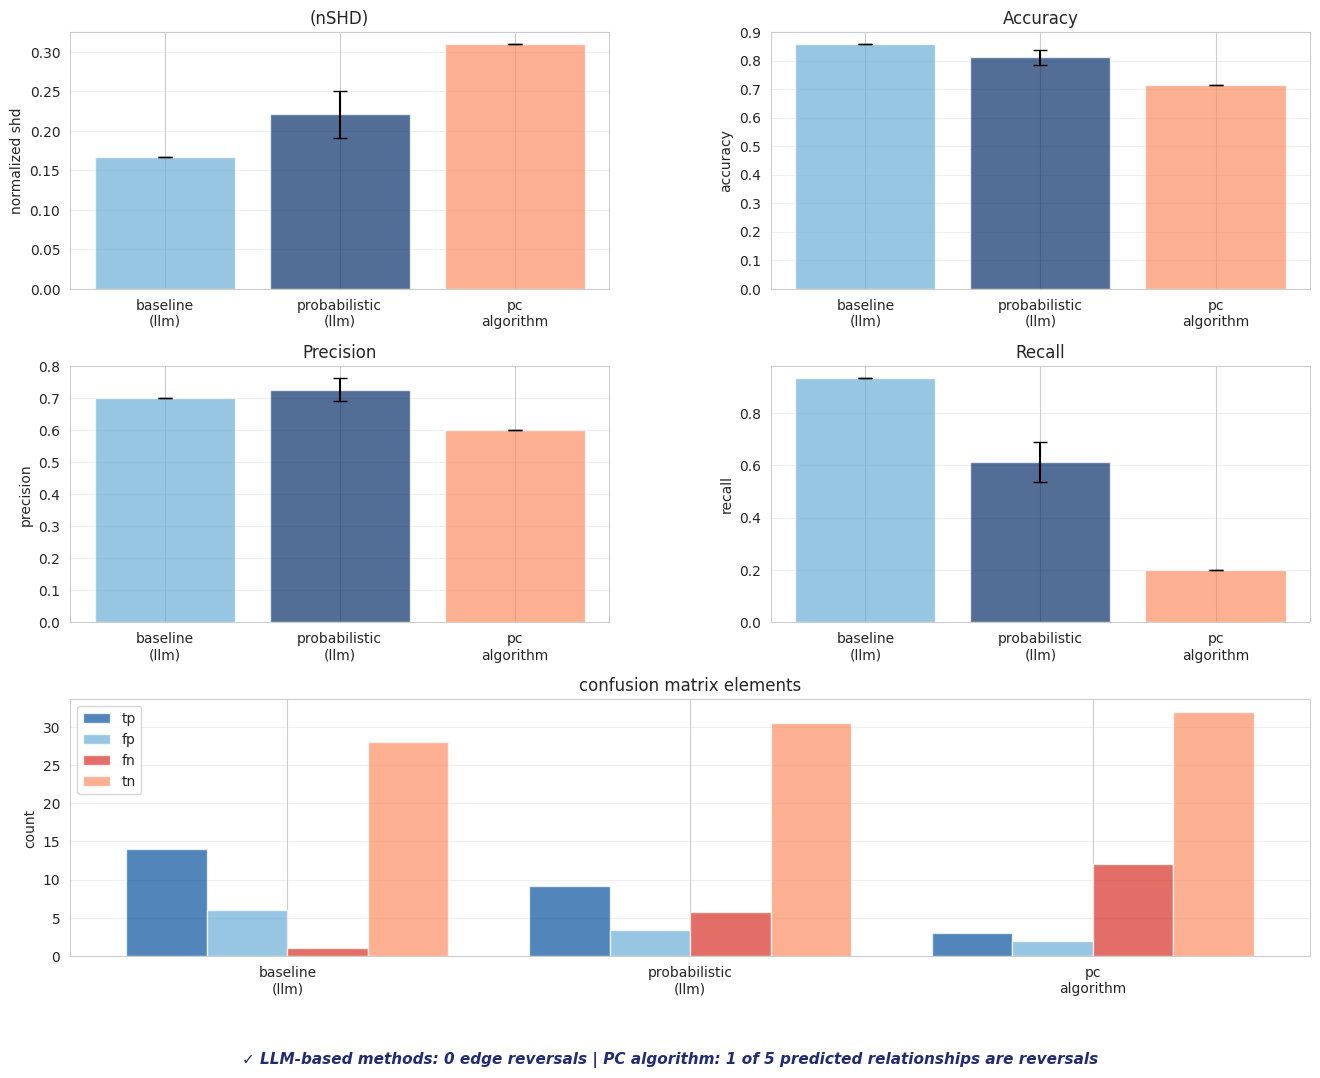

In [67]:
# visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

methods = ['baseline\n(llm)', 'probabilistic\n(llm)', 'pc\nalgorithm']
colors = ['#6BAED6', '#08306B', '#FC8D62']

# normalized shd comparison
ax1 = fig.add_subplot(gs[0, 0])
norm_shd_values = [baseline_metrics['norm_shd'], metrics_df['norm_shd'].mean(), pc_metrics['norm_shd']]
norm_shd_errors = [0, metrics_df['norm_shd'].std(), 0]
ax1.bar(methods, norm_shd_values, yerr=norm_shd_errors, capsize=5, alpha=0.7, color=colors)
ax1.set_ylabel('normalized shd')
ax1.set_title('(nSHD)')
ax1.grid(axis='y', alpha=0.3)

# accuracy comparison
ax2 = fig.add_subplot(gs[0, 1])
accuracy_values = [baseline_metrics['accuracy'], metrics_df['accuracy'].mean(), pc_metrics['accuracy']]
accuracy_errors = [0, metrics_df['accuracy'].std(), 0]
ax2.bar(methods, accuracy_values, yerr=accuracy_errors, capsize=5, alpha=0.7, color=colors)
ax2.set_ylabel('accuracy')
ax2.set_title('Accuracy')
ax2.grid(axis='y', alpha=0.3)

# precision comparison
ax3 = fig.add_subplot(gs[1, 0])
precision_values = [baseline_metrics['precision'], metrics_df['precision'].mean(), pc_metrics['precision']]
precision_errors = [0, metrics_df['precision'].std(), 0]
ax3.bar(methods, precision_values, yerr=precision_errors, capsize=5, alpha=0.7, color=colors)
ax3.set_ylabel('precision')
ax3.set_title('Precision')
ax3.grid(axis='y', alpha=0.3)

# recall comparison
ax4 = fig.add_subplot(gs[1, 1])
recall_values = [baseline_metrics['recall'], metrics_df['recall'].mean(), pc_metrics['recall']]
recall_errors = [0, metrics_df['recall'].std(), 0]
ax4.bar(methods, recall_values, yerr=recall_errors, capsize=5, alpha=0.7, color=colors)
ax4.set_ylabel('recall')
ax4.set_title('Recall')
ax4.grid(axis='y', alpha=0.3)

# confusion matrix comparison
ax5 = fig.add_subplot(gs[2, :])
x = np.arange(len(methods))
width = 0.2
tp_values = [baseline_metrics['tp'], metrics_df['tp'].mean(), pc_metrics['tp']]
fp_values = [baseline_metrics['fp'], metrics_df['fp'].mean(), pc_metrics['fp']]
fn_values = [baseline_metrics['fn'], metrics_df['fn'].mean(), pc_metrics['fn']]
tn_values = [baseline_metrics['tn'], metrics_df['tn'].mean(), pc_metrics['tn']]

metric_colors = {'tp': '#08519C', 'fp': '#6BAED6', 'fn': "#D73027", 'tn': "#FC8D62"}

ax5.bar(x - 1.5*width, tp_values, width, label='tp', alpha=0.7, color=metric_colors['tp'])
ax5.bar(x - 0.5*width, fp_values, width, label='fp', alpha=0.7, color=metric_colors['fp'])
ax5.bar(x + 0.5*width, fn_values, width, label='fn', alpha=0.7, color=metric_colors['fn'])
ax5.bar(x + 1.5*width, tn_values, width, label='tn', alpha=0.7, color=metric_colors['tn'])

ax5.set_ylabel('count')
ax5.set_title('confusion matrix elements')
ax5.set_xticks(x)
ax5.set_xticklabels(methods)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Add to the existing large plot after ax5 (confusion matrix)
fig.text(0.5, 0.02, '✓ LLM-based methods: 0 edge reversals | PC algorithm: {} of 5 predicted relationships are reversals'.format(pc_reversals), 
         ha='center', fontsize=11, style='italic', color="#212c74", weight='bold')

plt.savefig('method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
comparison_df = pd.DataFrame({
    'method': ['baseline (llm)', 'pc algorithm', 'probabilistic (llm)'],
    'shd': [
        baseline_metrics['shd'], 
        pc_metrics['shd'], 
        f"{metrics_df['shd'].mean():.2f} ± {metrics_df['shd'].std():.2f}"
    ],
    'norm_shd': [
        f"{baseline_metrics['norm_shd']:.3f}",
        f"{pc_metrics['norm_shd']:.3f}",
        f"{metrics_df['norm_shd'].mean():.3f} ± {metrics_df['norm_shd'].std():.3f}"
    ],
    'accuracy': [
        f"{baseline_metrics['accuracy']:.3f}",
        f"{pc_metrics['accuracy']:.3f}",
        f"{metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}"
    ],
    'precision': [
        f"{baseline_metrics['precision']:.3f}",
        f"{pc_metrics['precision']:.3f}",
        f"{metrics_df['precision'].mean():.3f} ± {metrics_df['precision'].std():.3f}"
    ],
    'recall': [
        f"{baseline_metrics['recall']:.3f}",
        f"{pc_metrics['recall']:.3f}",
        f"{metrics_df['recall'].mean():.3f} ± {metrics_df['recall'].std():.3f}"
    ],
    'tp': [baseline_metrics['tp'], pc_metrics['tp'], f"{metrics_df['tp'].mean():.1f}"],
    'fp': [baseline_metrics['fp'], pc_metrics['fp'], f"{metrics_df['fp'].mean():.1f}"],
    'fn': [baseline_metrics['fn'], pc_metrics['fn'], f"{metrics_df['fn'].mean():.1f}"],
    'tn': [baseline_metrics['tn'], pc_metrics['tn'], f"{metrics_df['tn'].mean():.1f}"]
})

print(comparison_df.to_string(index=False))

             method         shd      norm_shd      accuracy     precision        recall  tp  fp  fn   tn
     baseline (llm)           7         0.167         0.857         0.700         0.933  14   6   1   28
       pc algorithm        13.0         0.310         0.714         0.600         0.200   3   2  12   32
probabilistic (llm) 9.27 ± 1.24 0.221 ± 0.030 0.811 ± 0.025 0.726 ± 0.037 0.612 ± 0.078 9.2 3.4 5.8 30.6


In [62]:
def count_edge_reversals(adj_true, adj_pred):
    """Count edges where direction is reversed between true and predicted graphs"""
    n = len(adj_true)
    reversals = 0
    reversal_pairs = []
    
    for i in range(n):
        for j in range(i + 1, n):
            # Check if edge exists in opposite directions
            if (adj_true[i, j] == 1 and adj_pred[j, i] == 1 and adj_pred[i, j] == 0):
                reversals += 1
                reversal_pairs.append((i, j, 'predicted j->i instead of i->j'))
            elif (adj_true[j, i] == 1 and adj_pred[i, j] == 1 and adj_pred[j, i] == 0):
                reversals += 1
                reversal_pairs.append((i, j, 'predicted i->j instead of j->i'))
    
    return reversals, reversal_pairs

# Check baseline
baseline_reversals, baseline_pairs = count_edge_reversals(adjacency_gt, adjacency_baseline_reordered)

# Check PC algorithm
pc_reversals, pc_pairs = count_edge_reversals(adjacency_gt, adjacency_pc_reordered)

# Check probabilistic graphs
prob_reversals = []
for idx, graph in enumerate(loaded_graphs):
    if set(graph['variables']) != set(gt_variables):
        continue
    
    adj_pred_raw = np.array(graph['adjacency_matrix'])
    if graph['variables'] != gt_variables:
        reorder_indices = [graph['variables'].index(var) for var in gt_variables]
        adj_pred = adj_pred_raw[np.ix_(reorder_indices, reorder_indices)]
    else:
        adj_pred = adj_pred_raw
    
    reversals, _ = count_edge_reversals(adjacency_gt, adj_pred)
    prob_reversals.append(reversals)

print(f"Baseline (LLM): {baseline_reversals} edge reversals")
print(f"PC Algorithm: {pc_reversals} edge reversals")
print(f"Probabilistic (LLM): {np.mean(prob_reversals):.2f} ± {np.std(prob_reversals):.2f} edge reversals")

Baseline (LLM): 0 edge reversals
PC Algorithm: 1 edge reversals
Probabilistic (LLM): 0.00 ± 0.00 edge reversals


General analysis
While the baseline LLM achieves the lowest nSHD and highest Recall, it predicts a substantial number of false positive edges (FP = 6), reflecting hallucinated relationships. Introducing probabilistic constraints reduces these fake edges (FP = 3.4), improving Precision (0.726) at the cost of slightly lower Recall (0.612) and a modest increase in nSHD (0.221 ± 0.030). This trade-off favors more conservative, reliable causal discovery.

Baseline vs Probabilistic 

However, it enables critical uncertainty quantification: each edge receives a probability score derived from Monte Carlo samples, allowing clinicians to distinguish high-confidence causal relationships from uncertain associations requiring further validation (e.g., BMI → cardiac ischemia, prob=0.62). The baseline's lower SHD stems from including all 20 possible edges versus the ground truth's 15, at the cost of 6 false positive edges.

The key advantage of the probabilistic method lies in **false positive reduction**: it produces only 3.4 false positives on average (42% reduction) compared to the baseline's 6 spurious edges, while maintaining similar or higher precision (73% vs. 70%). The conservative nature of the approach (FN=5.8 > FP=3.4) reflects the Hallbayes refinement method preference to exclude uncertain edges rather than risk false relationships clinical contexts. 

Both approaches have zero edge reversals (correct causal directionality).


## PC Algorithm vs. LLM-Based Methods

The PC algorithm demonstrates significantly lower recall (20%) compared to LLM-based methods (93% baseline, 61% probabilistic), missing 12 of 15 true causal relationships in the ground truth graph. This poor performance comes from its reliance on conditional independence tests, which struggle with small complex confounding patterns between cardiovascular risk factors, non linear relationships, and measurement noise in real-world health records. In contrast, LLM-based methods leverage domain knowledge encoded during pre-training to identify plausible causal pathways even with limited data, achieving 3× higher recall while maintaining comparable or better precision (70-73% vs. 60%).

**Edge directionality**: LLM-based methods achieve perfect causal directionality with **zero edge reversals** 0 relationships incorrectly oriented, while the PC algorithm shows 1 of 5 predicted relationships with reversed direction. This demonstrates the LLM's superior understanding of causal directionality.

The accuracy is similar (81.1% vs. 85.7%). Despite being slightly lower, the probabilistic approach provides **distributional information** unavailable in deterministic baselines: confidence intervals for hSHD, edge probability distributions. This enables sensitivity analyses (e.g., "use only edges with high probability, and explainable decision-making. The methodology achieves competitive performance while answering the critical question deterministic methods cannot: "How confident should we be in this causal relationship?"